### ANNOVAR Installation and Initial Database Download
This cell downloads the ANNOVAR package, extracts it, and then uses `annotate_variation.pl`. This is a one-time setup for ANNOVAR.

In [ ]:
!wget http://www.openbioinformatics.org/annovar/download/0wgxR2rIVP/annovar.latest.tar.gz
!tar -zxvf annovar.latest.tar.gz

--2026-02-12 06:56:50--  http://www.openbioinformatics.org/annovar/download/0wgxR2rIVP/annovar.latest.tar.gz
Resolving www.openbioinformatics.org (www.openbioinformatics.org)... 67.205.156.247
Connecting to www.openbioinformatics.org (www.openbioinformatics.org)|67.205.156.247|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 280727629 (268M) [application/x-gzip]
Saving to: ‘annovar.latest.tar.gz’

annovar.latest.tar. 100%[===================>] 267.72M  41.4MB/s    in 6.2s    

2026-02-12 06:56:56 (43.4 MB/s) - ‘annovar.latest.tar.gz’ saved [280727629/280727629]

annovar/
annovar/example/
annovar/example/ex1.avinput
annovar/example/example.simple_region
annovar/example/example.tab_region
annovar/example/ex2.vcf
annovar/example/grantham.matrix
annovar/example/snplist.txt
annovar/example/README
annovar/example/gene_xref.txt
annovar/example/gene_fullxref.txt
annovar/humandb/
annovar/humandb/hg19_refGene.txt
annovar/humandb/hg19_refGeneMrna.fa
annovar/humandb/hg19_re

### Downloading ANNOVAR Databases
This section downloads several essential annotation databases (RefGene, gnomAD exome/genome, dbNSFP, ClinVar) that ANNOVAR will use to annotate the VCF variants. These databases provide information on gene function, population frequencies, functional predictions, and clinical significance.

In [ ]:
# RefGene
!cd annovar && perl annotate_variation.pl -buildver hg38 -downdb -webfrom annovar refGene humandb/

# gnomAD
!cd annovar && perl annotate_variation.pl -buildver hg38 -downdb -webfrom annovar gnomad_exome humandb/
!cd annovar && perl annotate_variation.pl -buildver hg38 -downdb -webfrom annovar gnomad_genome humandb/

# dbNSFP (functional prediction scores)
!cd annovar && perl annotate_variation.pl -buildver hg38 -downdb -webfrom annovar dbnsfp42a humandb/


NOTICE: Web-based checking to see whether ANNOVAR new version is available ... Done
NOTICE: Downloading annotation database http://www.openbioinformatics.org/annovar/download/hg38_refGene.txt.gz ... OK
NOTICE: Downloading annotation database http://www.openbioinformatics.org/annovar/download/hg38_refGeneMrna.fa.gz ... OK
NOTICE: Downloading annotation database http://www.openbioinformatics.org/annovar/download/hg38_refGeneVersion.txt.gz ... OK
NOTICE: Uncompressing downloaded files
NOTICE: Finished downloading annotation files for hg38 build version, with files saved at the 'humandb' directory
NOTICE: Web-based checking to see whether ANNOVAR new version is available ... Done
NOTICE: Downloading annotation database http://www.openbioinformatics.org/annovar/download/hg38_gnomad_exome.txt.gz ... OK
NOTICE: Downloading annotation database http://www.openbioinformatics.org/annovar/download/hg38_gnomad_exome.txt.idx.gz ... OK
NOTICE: Uncompressing downloaded files
NOTICE: Finished downloadi

### Updating ClinVar Database
Due to an older ClinVar database initially failing to download, this cell explicitly downloads a more recent version of the ClinVar database. This ensures access to the latest clinical significance interpretations for variants.

In [ ]:
# Replace with more recent version
!cd annovar && perl annotate_variation.pl -buildver hg38 -downdb -webfrom annovar clinvar_20240611 humandb/


NOTICE: Web-based checking to see whether ANNOVAR new version is available ... Done
NOTICE: Downloading annotation database http://www.openbioinformatics.org/annovar/download/hg38_clinvar_20240611.txt.gz ... OK
NOTICE: Downloading annotation database http://www.openbioinformatics.org/annovar/download/hg38_clinvar_20240611.txt.idx.gz ... OK
NOTICE: Uncompressing downloaded files
NOTICE: Finished downloading annotation files for hg38 build version, with files saved at the 'humandb' directory


### Mount Google Drive
This cell mounts your Google Drive, allowing the notebook to access files stored in your Drive, such as the VCF file for annotation.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/AI_WES_AD_Project/


AD_Cohort_111_merged.vcf


In [ ]:
# Copy VCF to ANNOVAR Directory
#This cell copies the input VCF file from Google Drive into the `annovar/` directory, making it accessible for ANNOVAR processing.

!cp /content/drive/MyDrive/AI_WES_AD_Project/AD_Cohort_111_merged.vcf annovar/



In [ ]:
!ls annovar/


AD_Cohort_111_merged.vcf  convert2annovar.pl  retrieve_seq_from_fasta.pl
annotate_variation.pl	  example	      table_annovar.pl
coding_change.pl	  humandb	      variants_reduction.pl


### Initial ANNOVAR Annotation
This cell performs the ANNOVAR annotation using the generated `AD_Cohort_111_merged.avinput` file.

### Corrected VCF to ANNOVAR Input Conversion (All Samples)
This crucial cell re-runs the VCF to `.avinput` conversion with the correct parameters (`-allsample -withfreq`) to ensure that all variants and allele frequencies from all 111 samples in the VCF are properly included in the new `AD_Cohort_111_merged2.avinput` file. This addresses the limitation of the first conversion attempt.

In [ ]:
!cd annovar && \
perl convert2annovar.pl -format vcf4 -allsample -withfreq AD_Cohort_111_merged.vcf \
> AD_Cohort_111_merged2.avinput

NOTICE: Finished reading 331689 lines from VCF file
NOTICE: A total of 331161 locus in VCF file passed QC threshold, representing 305041 SNPs (173782 transitions and 131259 transversions) and 26120 indels/substitutions
NOTICE: Finished writing allele frequencies based on 33859551 SNP genotypes (19289802 transitions and 14569749 transversions) and 2899320 indels/substitutions for 111 samples


### Comprehensive ANNOVAR Annotation (Based on All Samples Input)
This cell performs the ANNOVAR annotation using the `AD_Cohort_111_merged2.avinput` file, which now correctly includes data from all 111 samples. This will generate a complete and accurate annotation file (`AD_Cohort_111_2.hg38_multianno.csv`).

In [ ]:
# Run ANNOVAR annotation with downloaded databases
# -protocol and -operation must match the order of databases

!cd annovar && \
perl table_annovar.pl AD_Cohort_111_merged2.avinput humandb/ \
-buildver hg38 \
-out AD_Cohort_111_2 \
-remove \
-protocol refGene,gnomad_exome,gnomad_genome,dbnsfp42a,clinvar_20240611 \
-operation g,f,f,f,f \
-nastring . \
-csvout \
-polish \
-thread 4

-----------------------------------------------------------------
NOTICE: Processing operation=g protocol=refGene

NOTICE: Running with system command <annotate_variation.pl -geneanno -buildver hg38 -dbtype refGene -outfile AD_Cohort_111_2.refGene -exonsort -nofirstcodondel AD_Cohort_111_merged2.avinput humandb/ -thread 4>
NOTICE: Output files are written to AD_Cohort_111_2.refGene.variant_function, AD_Cohort_111_2.refGene.exonic_variant_function
NOTICE: the queryfile AD_Cohort_111_merged2.avinput contains 331161 lines
NOTICE: threading is disabled for gene-based annotation on file with less than 1000000 input lines
NOTICE: Reading gene annotation from humandb/hg38_refGene.txt ... Done with 88819 transcripts (including 21511 without coding sequence annotation) for 28307 unique genes
NOTICE: Processing next batch with 331161 unique variants in 331161 input lines
NOTICE: Reading FASTA sequences from humandb/hg38_refGeneMrna.fa ... Done with 54928 sequences

NOTICE: Running with system co

In [ ]:
!ls annovar/


AD_Cohort_111_2.hg38_multianno.csv	    coding_change.pl
AD_Cohort_111_merged2.avinput		    convert2annovar.pl
AD_Cohort_111_merged.avinput		    example
AD_Cohort_111_merged.vcf		    humandb
AD_Cohort_111_multianno.hg38_multianno.csv  retrieve_seq_from_fasta.pl
AD_Cohort_111_multianno.html		    table_annovar.pl
annotate_variation.pl			    variants_reduction.pl


In [ ]:
import pandas as pd

# Load the new annotated CSV file into a DataFrame
df_annovar_2 = pd.read_csv('annovar/AD_Cohort_111_2.hg38_multianno.csv')

# Display the first 5 rows of the DataFrame
display(df_annovar_2.head())

,Chr,Start,End,Ref,Alt,Func.refGene,Gene.refGene,GeneDetail.refGene,ExonicFunc.refGene,AAChange.refGene,...,SiPhy_29way_logOdds,SiPhy_29way_logOdds_rankscore,Interpro_domain,GTEx_V8_gene,GTEx_V8_tissue,CLNALLELEID,CLNDN,CLNDISDB,CLNREVSTAT,CLNSIG
0,chr1,13213,13213,C,A,ncRNA_intronic,DDX11L1,.,.,.,...,.,.,.,.,.,.,.,.,.,.
1,chr1,13668,13668,G,A,ncRNA_exonic,DDX11L1,.,.,.,...,.,.,.,.,.,.,.,.,.,.
2,chr1,16856,16856,A,G,ncRNA_splicing,WASH7P,NR_024540:exon7:c.921+2T>C,.,.,...,.,.,.,.,.,.,.,.,.,.
3,chr1,17375,17375,A,G,ncRNA_exonic,"MIR6859-1,MIR6859-2,MIR6859-3,MIR6859-4",.,.,.,...,.,.,.,.,.,.,.,.,.,.
4,chr1,69428,69428,T,G,exonic,OR4F5,.,nonsynonymous SNV,OR4F5:NM_001005484:exon1:c.T338G:p.F113C,...,4.491,0.112,GPCR\x2c rhodopsin-like\x2c 7TM;GPCR\x2c rhodo...,.,.,.,.,.,.,.


In [ ]:
df_annovar_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331161 entries, 0 to 331160
Columns: 139 entries, Chr to CLNSIG
dtypes: int64(2), object(137)
memory usage: 351.2+ MB


In [ ]:
df_annovar_2.head()
df_annovar_2.columns

Index(['Chr', 'Start', 'End', 'Ref', 'Alt', 'Func.refGene', 'Gene.refGene',
       'GeneDetail.refGene', 'ExonicFunc.refGene', 'AAChange.refGene',
       ...
       'SiPhy_29way_logOdds', 'SiPhy_29way_logOdds_rankscore',
       'Interpro_domain', 'GTEx_V8_gene', 'GTEx_V8_tissue', 'CLNALLELEID',
       'CLNDN', 'CLNDISDB', 'CLNREVSTAT', 'CLNSIG'],
      dtype='object', length=139)

In [ ]:
display(df_annovar_2.describe())

,Start,End
count,3.311610e+05,3.311610e+05
mean,7.513917e+07,7.513917e+07
std,5.686272e+07,5.686272e+07
min,1.289700e+04,1.289700e+04
25%,3.096570e+07,3.096570e+07
50%,6.196897e+07,6.196897e+07
75%,1.113629e+08,1.113629e+08
max,2.489178e+08,2.489178e+08


# Task
Analyze and visualize the distribution of variant types based on 'Func.refGene' and 'ExonicFunc.refGene' columns in the `df_annovar_2` DataFrame.

## Initial Data Inspection

### Subtask:
Provide a basic overview of the DataFrame, including its structure, data types, and descriptive statistics.


## Variant Type Distribution Analysis

### Subtask:
Analyze and visualize the distribution of variant types based on 'Func.refGene' and 'ExonicFunc.refGene'.


**Reasoning**:
To analyze and visualize the distribution of variant types, I will import the necessary plotting libraries, calculate value counts for 'Func.refGene' and 'ExonicFunc.refGene' columns, and then create and display bar plots for each distribution.



/tmp/ipython-input-319133059.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=func_counts.index, y=func_counts.values, palette='viridis')


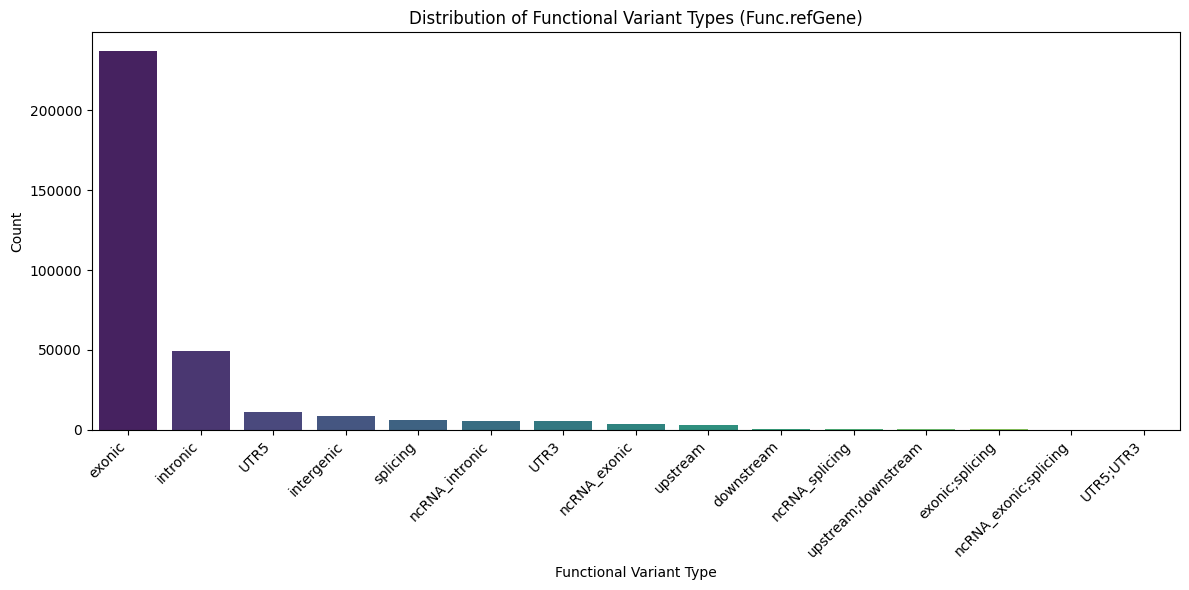

/tmp/ipython-input-319133059.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exonic_func_counts.index, y=exonic_func_counts.values, palette='plasma')


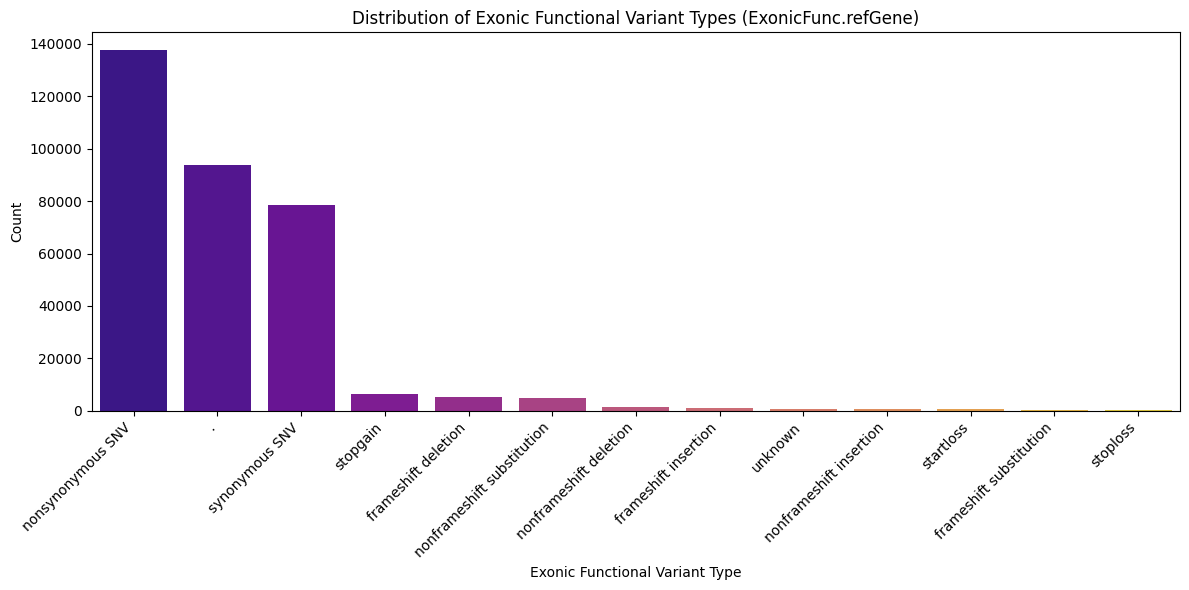

Plots generated showing the distribution of variant types based on 'Func.refGene' and 'ExonicFunc.refGene'.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate value counts for 'Func.refGene'
func_counts = df_annovar_2['Func.refGene'].value_counts()

# Create a bar plot for 'Func.refGene' distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=func_counts.index, y=func_counts.values, palette='viridis')
plt.title('Distribution of Functional Variant Types (Func.refGene)')
plt.xlabel('Functional Variant Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Calculate value counts for 'ExonicFunc.refGene'
exonic_func_counts = df_annovar_2['ExonicFunc.refGene'].value_counts()

# Create a bar plot for 'ExonicFunc.refGene' distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=exonic_func_counts.index, y=exonic_func_counts.values, palette='plasma')
plt.title('Distribution of Exonic Functional Variant Types (ExonicFunc.refGene)')
plt.xlabel('Exonic Functional Variant Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Plots generated showing the distribution of variant types based on 'Func.refGene' and 'ExonicFunc.refGene'.")

**Reasoning**:
The previous code produced a `FutureWarning` regarding the usage of `palette` without `hue` in `seaborn.barplot`. To address this, I will update the `sns.barplot` calls to include `hue=func_counts.index` (or `exonic_func_counts.index` respectively) and `legend=False` to explicitly handle the color mapping and suppress the warning, while maintaining the desired visualization.



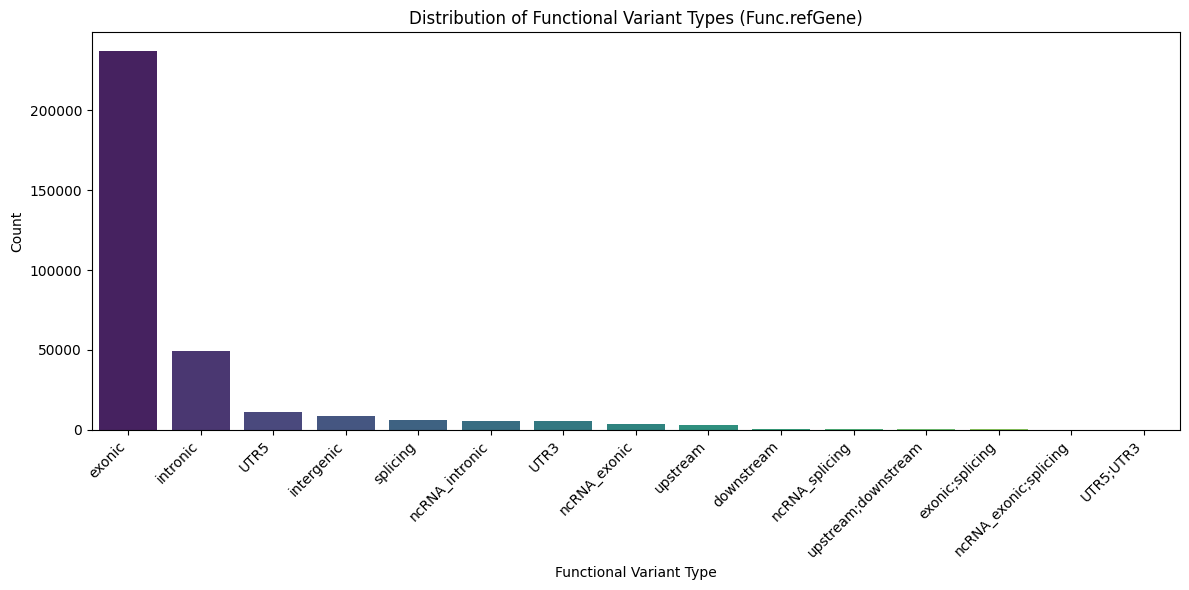

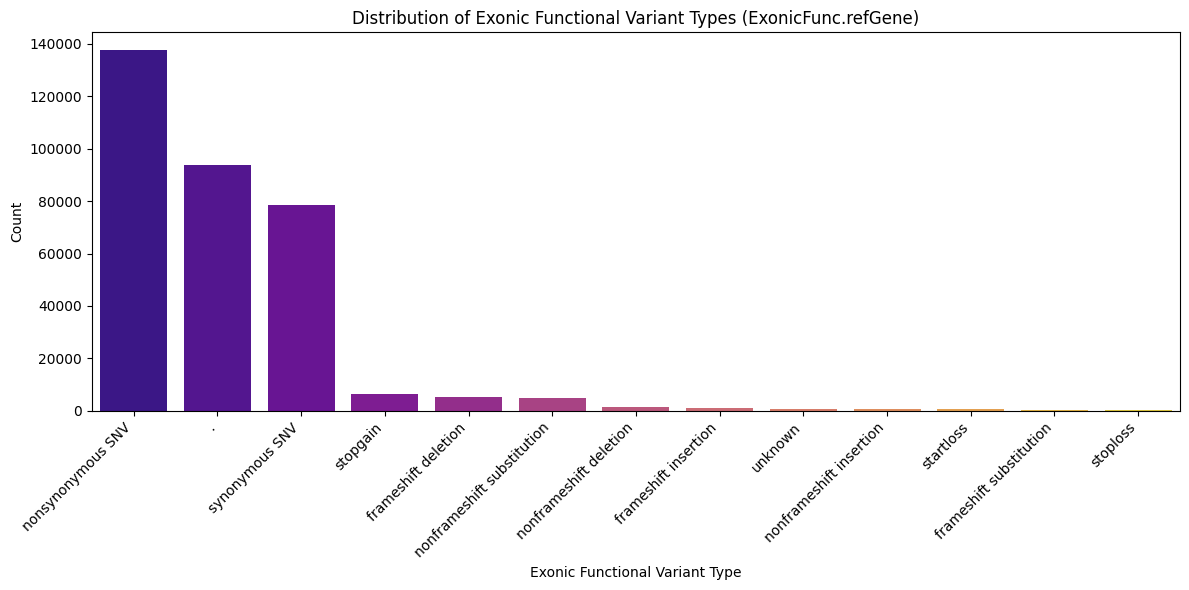

Plots generated showing the distribution of variant types based on 'Func.refGene' and 'ExonicFunc.refGene'.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate value counts for 'Func.refGene'
func_counts = df_annovar_2['Func.refGene'].value_counts()

# Create a bar plot for 'Func.refGene' distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=func_counts.index, y=func_counts.values, hue=func_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Functional Variant Types (Func.refGene)')
plt.xlabel('Functional Variant Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Calculate value counts for 'ExonicFunc.refGene'
exonic_func_counts = df_annovar_2['ExonicFunc.refGene'].value_counts()

# Create a bar plot for 'ExonicFunc.refGene' distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=exonic_func_counts.index, y=exonic_func_counts.values, hue=exonic_func_counts.index, palette='plasma', legend=False)
plt.title('Distribution of Exonic Functional Variant Types (ExonicFunc.refGene)')
plt.xlabel('Exonic Functional Variant Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Plots generated showing the distribution of variant types based on 'Func.refGene' and 'ExonicFunc.refGene'.")

## ClinVar Significance Analysis

### Subtask:
Summarize and visualize the distribution of clinical significance interpretations ('CLNSIG') from ClinVar.


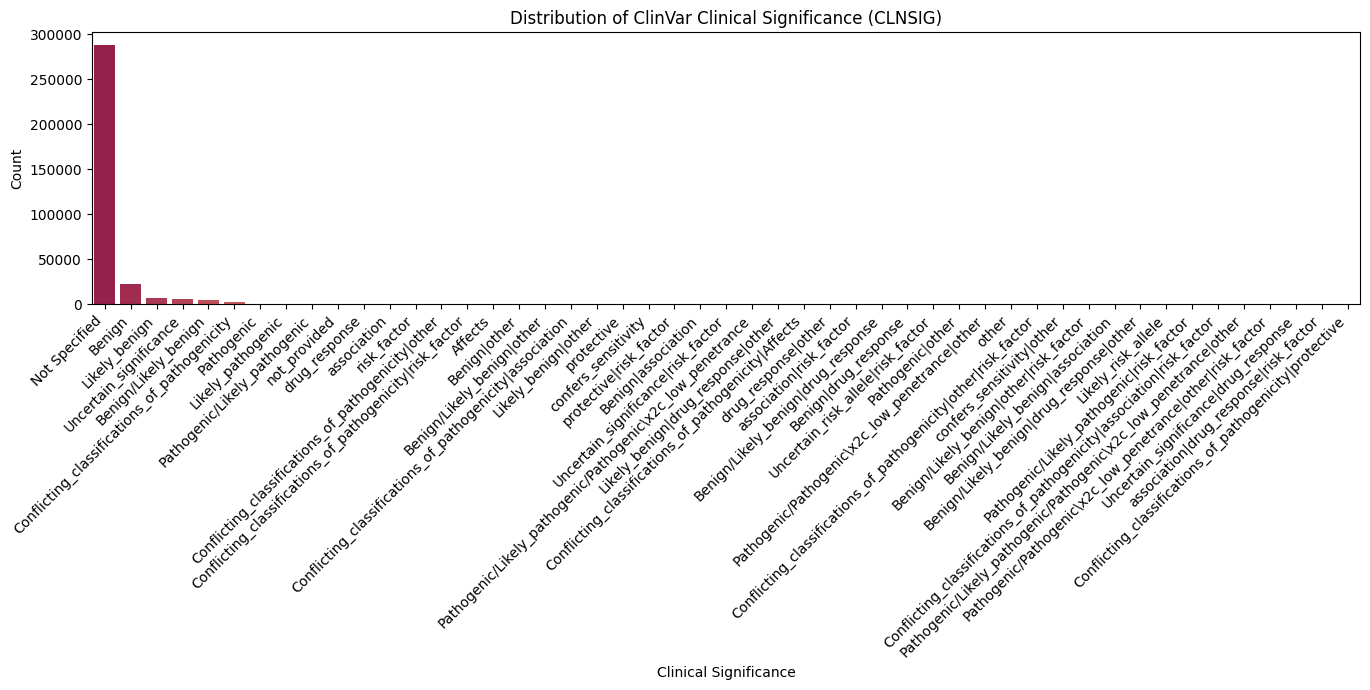

Bar plot generated showing the distribution of ClinVar clinical significance.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fill missing values ('.') in 'CLNSIG' with 'Not Specified'
df_annovar_2['CLNSIG'] = df_annovar_2['CLNSIG'].replace('.', 'Not Specified')

# Calculate value counts for 'CLNSIG'
clnsig_counts = df_annovar_2['CLNSIG'].value_counts()

# Create a bar plot for 'CLNSIG' distribution
plt.figure(figsize=(14, 7))
sns.barplot(x=clnsig_counts.index, y=clnsig_counts.values, hue=clnsig_counts.index, palette='Spectral', legend=False)
plt.title('Distribution of ClinVar Clinical Significance (CLNSIG)')
plt.xlabel('Clinical Significance')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Bar plot generated showing the distribution of ClinVar clinical significance.")